In [35]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [36]:
df = pd.read_csv('spam1.csv')
df.head()


,v1,v2
0,spam,Sample message number 0 for spam category.
1,ham,Sample message number 1 for ham category.
2,ham,Sample message number 2 for ham category.
3,spam,Sample message number 3 for spam category.
4,ham,Sample message number 4 for ham category.


In [37]:
# Separating target variable from the dataset
X = df.iloc[:, 1]
y = df.iloc[:, 0]


In [38]:
X.head()

0    Sample message number 0 for spam category.
1     Sample message number 1 for ham category.
2     Sample message number 2 for ham category.
3    Sample message number 3 for spam category.
4     Sample message number 4 for ham category.
Name: v2, dtype: object

In [39]:
y.head()

0    spam
1     ham
2     ham
3    spam
4     ham
Name: v1, dtype: object

In [40]:
!pip install wordcloud
!pip install fonttools
!pip install pillow==9.5.0
# after run this close the jupyter and reopen it and then go ahead



Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [41]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Filter the DataFrame to include only spam messages
spam_text = " ".join(df[df['v1'] == "spam"]['v2'].astype(str))  # Convert to string if needed

spam_text

'Sample message number 0 for spam category. Sample message number 3 for spam category. Sample message number 6 for spam category. Sample message number 9 for spam category. Sample message number 12 for spam category. Sample message number 15 for spam category. Sample message number 18 for spam category. Sample message number 21 for spam category. Sample message number 24 for spam category. Sample message number 27 for spam category. Sample message number 30 for spam category. Sample message number 33 for spam category. Sample message number 36 for spam category. Sample message number 39 for spam category. Sample message number 42 for spam category. Sample message number 45 for spam category. Sample message number 48 for spam category.'

In [42]:
# Generate the word cloud
wordcloud = WordCloud(
    width=600,
    height=200,
    background_color='white',
    colormap='viridis'
).generate(spam_text)


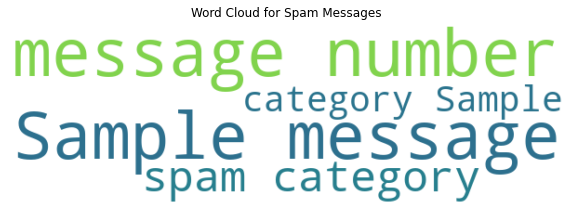

In [43]:

# Plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Hide axes
plt.title("Word Cloud for Spam Messages")
plt.show()


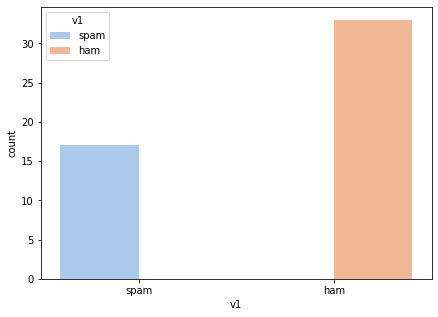

In [44]:
# Visualize the class distribution
fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(x='v1', data=df, palette='pastel', hue='v1')

for p in ax.patches:
    percentage = '{:.1f}'.format(100 * p.get_height() / len(df))
    x_countplot = p.get_x() + p.get_width() / 2
    y_countplot = p.get_height() + 50
    ax.annotate(percentage, (x_countplot, y_countplot), ha='center')

plt.show()


In [45]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X.values.ravel(),
    y.values.ravel(),
    test_size=0.3,
    random_state=42
)


In [46]:
X_train

array(['Sample message number 6 for spam category.',
       'Sample message number 41 for ham category.',
       'Sample message number 46 for ham category.',
       'Sample message number 47 for ham category.',
       'Sample message number 15 for spam category.',
       'Sample message number 9 for spam category.',
       'Sample message number 16 for ham category.',
       'Sample message number 24 for spam category.',
       'Sample message number 34 for ham category.',
       'Sample message number 31 for ham category.',
       'Sample message number 0 for spam category.',
       'Sample message number 44 for ham category.',
       'Sample message number 27 for spam category.',
       'Sample message number 33 for spam category.',
       'Sample message number 5 for ham category.',
       'Sample message number 29 for ham category.',
       'Sample message number 11 for ham category.',
       'Sample message number 36 for spam category.',
       'Sample message number 1 for ham ca

In [47]:
y_train

array(['spam', 'ham', 'ham', 'ham', 'spam', 'spam', 'ham', 'spam', 'ham',
       'ham', 'spam', 'ham', 'spam', 'spam', 'ham', 'ham', 'ham', 'spam',
       'ham', 'spam', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham',
       'spam', 'ham', 'ham', 'ham', 'spam', 'ham', 'ham', 'ham'],
      dtype=object)

In [52]:
# Creating Pipelining for Model Training
count_vectorizer = CountVectorizer()
tfidf_vectorizer = TfidfVectorizer()

clf_method = KNeighborsClassifier()

clf_count_vectorizer = Pipeline([
    ('vectorizer', count_vectorizer),
    #('to_dense', FunctionTransformer(lambda x: x.toarray(), validate=False)),  # Convert to dense for GNB
    ('classifier', clf_method)
])

clf_count_vectorizer.fit(X_train, y_train)


Pipeline(steps=[('vectorizer', CountVectorizer()),
                ('classifier', KNeighborsClassifier())])

In [53]:
clf_tfidf_vectorizer = Pipeline([
    ('vectorizer', tfidf_vectorizer),
    # ('to_dense', FunctionTransformer(lambda x: x.toarray(), validate=False)),  # Convert to dense for GNB
    ('classifier', clf_method)
])

clf_tfidf_vectorizer.fit(X_train, y_train)


Pipeline(steps=[('vectorizer', TfidfVectorizer()),
                ('classifier', KNeighborsClassifier())])

In [54]:
y_train_pred_cvect = clf_count_vectorizer.predict(X_train)
y_train_pred_tfidf_vect = clf_tfidf_vectorizer.predict(X_train)

print(f'Train Accuracy using Count Vectorizer: {accuracy_score(y_train, y_train_pred_cvect)}')
print(f'Train Accuracy using TF-IDF Vectorizer: {accuracy_score(y_train, y_train_pred_tfidf_vect)}')


Train Accuracy using Count Vectorizer: 1.0
Train Accuracy using TF-IDF Vectorizer: 1.0


In [55]:
y_test_pred_cvect = clf_count_vectorizer.predict(X_test)
y_test_pred_tfidf_vect = clf_tfidf_vectorizer.predict(X_test)

print(f'Test Accuracy using Count Vectorizer: {accuracy_score(y_test, y_test_pred_cvect)}')
print(f'Test Accuracy using TF-IDF Vectorizer: {accuracy_score(y_train, y_train_pred_tfidf_vect)}')


Test Accuracy using Count Vectorizer: 1.0
Test Accuracy using TF-IDF Vectorizer: 1.0


In [56]:
report = classification_report(y_test, y_test_pred_cvect)
print(report)


              precision    recall  f1-score   support

         ham       1.00      1.00      1.00         9
        spam       1.00      1.00      1.00         6

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



In [57]:
report = classification_report(y_test, y_test_pred_tfidf_vect)
print(report)


              precision    recall  f1-score   support

         ham       1.00      1.00      1.00         9
        spam       1.00      1.00      1.00         6

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



In [58]:
cm = confusion_matrix(y_test, y_test_pred_cvect)
cm


array([[9, 0],
       [0, 6]], dtype=int64)

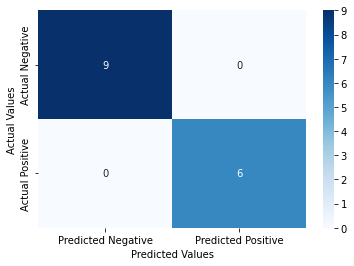

In [59]:
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])

plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show();
